In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

we collect the data

In [2]:
df = pd.read_csv("../data/Fraud.csv")

We read the data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [4]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [5]:
df.shape

(6362620, 11)

In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
print("=" * 50)
print(f"No. of unique steps : {df['step'].nunique()}")
print(f"No. of unique transaction type : {df['type'].nunique()}")
print("=" * 50)

No. of unique steps : 743
No. of unique transaction type : 5


In [10]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [11]:
df['isFraud'].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

Data is very highly imbalanced, need to fix it.

In [12]:
df['isFlaggedFraud'].value_counts(normalize=True) * 100

isFlaggedFraud
0    99.999749
1     0.000251
Name: proportion, dtype: float64

In [13]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [14]:
pd.crosstab(df['isFlaggedFraud'], df['isFraud'])

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


In [15]:
df.drop(columns="isFlaggedFraud" , inplace=True)

isflaggedFraud features tells out of actual fraud, how many the existing model detected. Here it detects only 16 which is not even quite good so better to drop this feature as it will not add much value to model.

In [16]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='str')

### Basic features extraction

In [17]:
df['origType'] = df['nameOrig'].str[0]

In [18]:
df['destType'] = df['nameDest'].str[0]

In [19]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

In [20]:
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [21]:
df['origType'].value_counts()

origType
C    6362620
Name: count, dtype: int64

In [22]:
df['destType'].value_counts()

destType
C    4211125
M    2151495
Name: count, dtype: int64

origType feature has only 1 value so better to drop as it will not add any value to model.

In [23]:
cols = [col for col in df.columns if col != "isFraud"] + ['isFraud']
df = df[cols]

In [24]:
df.drop(columns=["nameOrig" , "nameDest" , "origType"] , inplace=True)

These 3 features are not adding any value, even they will increase the computational time so better to drop.

# Exploratory Data Analysis

In [25]:
num_cols = df.select_dtypes(include="number")

In [26]:
cat_cols = df.select_dtypes(include=["object" , "string" , "category"])

In [27]:
df.select_dtypes(include="number").corr()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDiffOrig,balanceDiffDest,isFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.007255,0.001325,0.031578
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.102337,0.845964,0.076688
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,-0.220297,-0.087032,0.010154
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.267750,-0.094456,-0.008148
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.047460,0.232316,-0.005885
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,-0.006451,0.436191,0.000535
balanceDiffOrig,0.007255,0.102337,-0.220297,-0.267750,-0.047460,-0.006451,1.000000,0.169292,0.362472
balanceDiffDest,0.001325,0.845964,-0.087032,-0.094456,0.232316,0.436191,0.169292,1.000000,0.027028
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,0.362472,0.027028,1.000000


In [28]:
df.groupby("destType")['isFraud'].agg(["mean", "count"])

,mean,count
destType,,
C,0.00195,4211125
M,0.00000,2151495


In [29]:
pd.crosstab(df['isFraud'] , df['destType'])

destType,C,M
isFraud,,
0,4202912,2151495
1,8213,0


Every Fraudulent transaction done has C (customer account) as transaction destination.

<Axes: xlabel='destType', ylabel='count'>

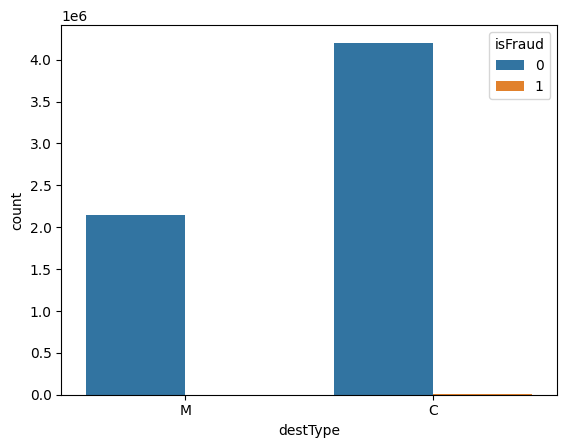

In [30]:
sns.countplot(x='destType', hue='isFraud', data=df)

<Axes: xlabel='type', ylabel='Count'>

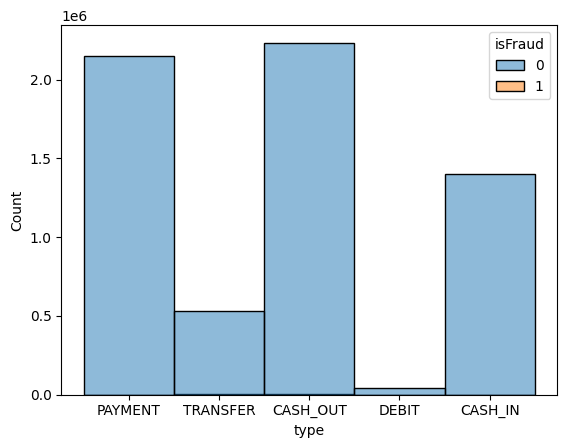

In [31]:
sns.histplot(data=df, x='type', hue='isFraud')

In [32]:
df.groupby('type')['isFraud'].mean() * 100

type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64

We got an important insight
- Fraud is heavily concentrated on 2 types of transaction only -- CASH_OUT (18.3%) and TRANSFER (76.87%) 

<Axes: xlabel='amount', ylabel='Count'>

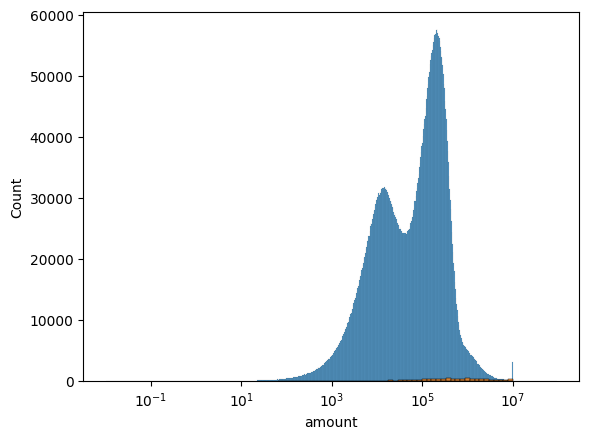

In [33]:
sns.histplot(df[df['isFraud']==0]['amount'], log_scale=True)
sns.histplot(df[df['isFraud']==1]['amount'], log_scale=True)

<Axes: xlabel='isFraud', ylabel='amount'>

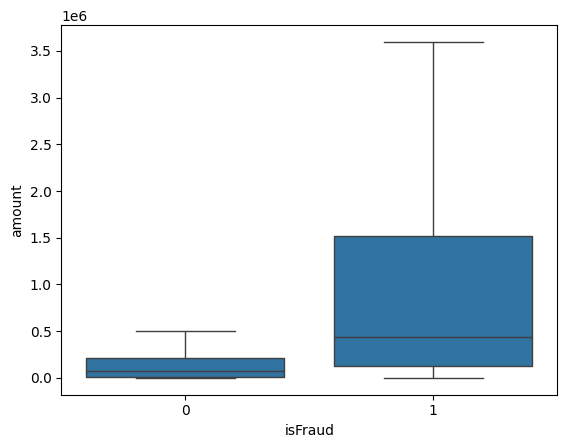

In [34]:
sns.boxplot(x='isFraud', y='amount', data=df, showfliers=False)

Amount variance is very high in case of fraud.

Text(0.5, 1.0, 'Amount Distribution with KDE')

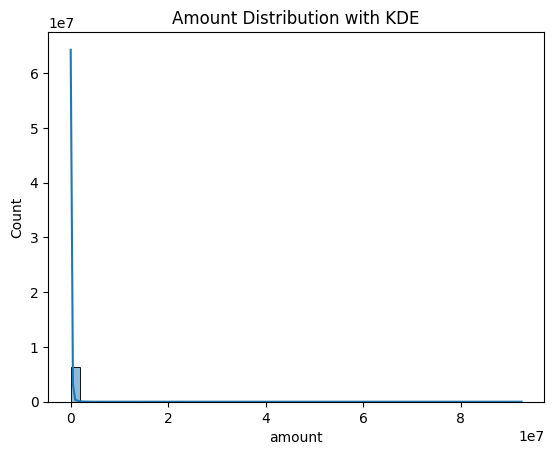

In [35]:
sns.histplot(df['amount'], bins=50, kde=True)
plt.title("Amount Distribution with KDE")

Amount is highly right skewed, mostly large transactions.

### Final Insights
Useful Features :
- type
- amount
- balanceDiffOrig
- desType

In [36]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,destType,balanceDiffOrig,balanceDiffDest,isFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,M,9839.64,0.0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,M,1864.28,0.0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,C,181.00,0.0,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,C,181.00,-21182.0,1
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,M,11668.14,0.0,0


In [51]:
df.tail()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,destType,balanceDiffOrig,balanceDiffDest,isFraud
6362615,743,CASH_OUT,339682.13,339682.13,0.0,0.00,339682.13,C,339682.13,339682.13,1
6362616,743,TRANSFER,6311409.28,6311409.28,0.0,0.00,0.00,C,6311409.28,0.00,1
6362617,743,CASH_OUT,6311409.28,6311409.28,0.0,68488.84,6379898.11,C,6311409.28,6311409.27,1
6362618,743,TRANSFER,850002.52,850002.52,0.0,0.00,0.00,C,850002.52,0.00,1
6362619,743,CASH_OUT,850002.52,850002.52,0.0,6510099.11,7360101.63,C,850002.52,850002.52,1
